# Pseudo to Physical-GCMC

np.mean(valid_data['energies'])_run_isotherm:0.0
energies[0]_analytic_isotherm:0.0
Henry constant (physical): 1e-05


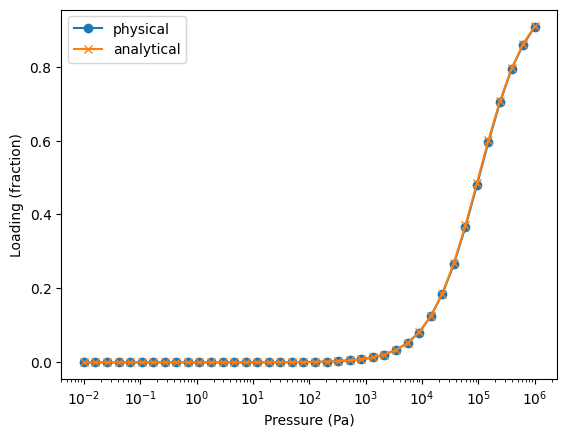

In [1]:
### --- import block --- ###
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from c01_isotherm_simulation import IsothermSimulator
from c01_compute_henry_constant import compute_henry_constant
from c01_energy_calculators import EnergyCalculator
from c01_chemical_potential_models import ChemicalPotentialModel


# ==========================================================
# Main Execution
# ==========================================================

if __name__ == "__main__":

    T = 298.0

    # サンプリング圧力は対数で与える
    pressures = np.logspace(-2, 6, 40)  # 10^2 – 10^6 Pa(10 bar)

    # pressures = np.array([1000.0])


    # 単位変換
    angstrom = 1e-10
    kJmol_to_J = 1000.0 / 6.02214076e23

    # --- Box ---
    box = np.array([30.0, 30.0, 30.0]) * angstrom

    # --- Framework positions ---
    # framework_positions = np.random.uniform(
    # 0, 15, size=(64,3)
    # ) * angstrom


    coords = np.linspace(0, 15, 4)  # Å
    framework_positions = []

    for x in coords:
        for y in coords:
            for z in coords:
                framework_positions.append([x, y, z])

    framework_positions = np.array(framework_positions) * angstrom

    # 原子数を取得
    num_atoms = len(framework_positions)

    # --- LJ parameters ---
    framework_sigmas = np.full(num_atoms, 3.5 * angstrom)
    framework_epsilons = np.full(num_atoms, 1.0 * kJmol_to_J) # 0.5 * kJmol_to_J


    # --- LJ parameters ---
    ads_sigma = 3.73 * angstrom
    ads_epsilon = 0.0 * kJmol_to_J # 1.23 * kJmol_to_J 3.0

    # --- gas parameter --- #
    m_molar = 0.016  # kg/mol

    # --- grid points（ランダム1000点） ---
    np.random.seed(0)

    # --- grid points（均一格子 0.5Å刻み） ---
    res = 1.0 * angstrom # 最初は粗目にしておくのがベター(後で0.5にするのはOK)
    x = np.arange(0, box[0], res)
    y = np.arange(0, box[1], res)
    z = np.arange(0, box[2], res)
    gx, gy, gz = np.meshgrid(x, y, z)
    grid_points = np.c_[gx.ravel(), gy.ravel(), gz.ravel()]
    cutoff = 12.0 * angstrom

    min_allowed_distance = 2.5 * angstrom # 現コードでは既に使っていない

    params = {
        "grid_points": grid_points,

        "min_allowed_distance": min_allowed_distance,

        "framework": {
            "framework_name": "ToyMOF",
            "framework_positions": framework_positions,
            "framework_sigmas": framework_sigmas,
            "framework_epsilons": framework_epsilons,
        },

        "adsorbate": {
            "adsorbate_name": "CH4",
            "m_molar": m_molar,  # kg/mol
            "adsorbate_sigma": ads_sigma,
            "adsorbate_epsilon": ads_epsilon,
        },

        "boundary": {
            "box": box,
            "cutoff": cutoff,
        }
    }

    # Isotherm Simulation
    # mu0_list = np.linspace(-10000, 10000, 5)

    mu0_value = 0.0 # 比較用なら0.0でOK（絶対値が知りたいなら別）

    # for mu0_value in mu0_list:
        # print(f"mu0_value: {mu0_value}")
    mc_isotherm, analytic_iso, valid_data, mu, N_history = IsothermSimulator.run_isotherm(params, T, pressures, mu0_value)

    # Henry constant
    KH = compute_henry_constant(valid_data["energies"], T, P0=1e5)
    print("Henry constant (physical):", KH)

    # result plot
    plt.figure()
    plt.semilogx(pressures, mc_isotherm, marker='o', label="physical")
    plt.semilogx(pressures, analytic_iso, marker='x', label="analytical")
    plt.xlabel("Pressure (Pa)")
    plt.ylabel("Loading (fraction)")
    plt.legend()
    plt.show()



In [2]:
R_GAS = 8.314

print(f'mu:{mu}')
print(f'mu/RT:{mu / (R_GAS*T)}')
print(f'eps/RT: {np.mean(valid_data["energies"]) / (R_GAS*T)}')


mu:5705.137788777988
mu/RT:2.302713216317422
eps/RT: 0.0


In [3]:
import numpy as np

print("mean:", np.mean(valid_data["energies"]))
print("std:", np.std(valid_data["energies"]))
print("min:", np.min(valid_data["energies"]))
print("max:", np.max(valid_data["energies"]))

# 上位10個を見る
print(np.sort(valid_data["energies"])[-10:])



mean: 0.0
std: 0.0
min: 0.0
max: 0.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


C:\Users\y_7up\AppData\Local\Temp\ipykernel_21136\3141688349.py:22: RuntimeWarning: overflow encountered in exp
  weights = comb(M, N_values) * np.exp(beta * mu * N_values)
C:\Users\y_7up\AppData\Local\Temp\ipykernel_21136\3141688349.py:22: RuntimeWarning: overflow encountered in multiply
  weights = comb(M, N_values) * np.exp(beta * mu * N_values)
C:\Users\y_7up\AppData\Local\Temp\ipykernel_21136\3141688349.py:23: RuntimeWarning: invalid value encountered in divide
  P_theory = weights / np.sum(weights)


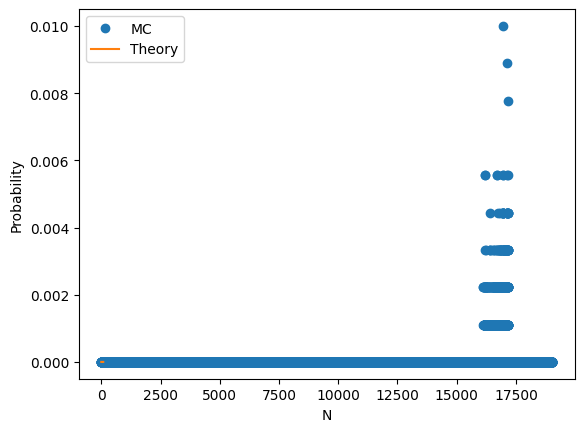

MC mean: 16775.226666666666
Theory mean: nan


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

# --- 取得 ---
N_history = np.array(N_history)

M = len(valid_data["energies"])
beta = 1.0 / (R_GAS * T)
mu = mu

# --- MCヒストグラム ---
hist, bins = np.histogram(
    N_history,
    bins=np.arange(0, M+2) - 0.5,
    density=True
)

N_values = np.arange(0, M+1)

# --- 理論分布 ---
weights = comb(M, N_values) * np.exp(beta * mu * N_values)
P_theory = weights / np.sum(weights)

# --- プロット ---
plt.plot(N_values, hist, 'o', label='MC')
plt.plot(N_values, P_theory, '-', label='Theory')
plt.xlabel("N")
plt.ylabel("Probability")
plt.legend()
plt.show()

# --- 平均値比較 ---
print("MC mean:", np.mean(N_history))
print("Theory mean:", np.sum(N_values * P_theory))



In [4]:
print(mc_isotherm)

[1.89005954e-07 2.93801335e-07 5.70760554e-07 8.10292853e-07
 1.33239841e-06 2.12584915e-06 3.26175622e-06 5.08257595e-06
 7.67251893e-06 1.18699482e-05 1.78170860e-05 2.59892544e-05
 3.78666879e-05 5.42147673e-05 7.94741967e-05 1.21244513e-04
 1.92391219e-04 3.05603914e-04 4.91615715e-04 7.85452605e-04
 1.25851205e-03 2.03429728e-03 3.23414825e-03 5.17296571e-03
 8.34114527e-03 1.33074189e-02 2.10953662e-02 3.32438194e-02
 5.26808343e-02 8.09255322e-02 1.24119591e-01 1.84137887e-01
 2.65670209e-01 3.61491785e-01 4.76197924e-01 5.91906337e-01
 7.02168486e-01 7.90810652e-01 8.59840954e-01 9.07862893e-01]


## データ保存

In [ ]:
# import pandas as pd

# df_isotherm_single = pd.DataFrame(
#     {
#     "pressure": pressures,
#     "theta": iso_single
#     },
# ).astype(float)

# display(df_isotherm_single.head())

# single_save_to = r"C:\Users\y_7up\Documents\projects\mi_dev\04_mof\output\gcmc\isotherm_single.csv"

# df_isotherm_single.to_csv(single_save_to, encoding="utf-8", index=False)

# df_isotherm_dual = pd.DataFrame(
#     {
#     "pressure": pressures,
#     "theta": iso_dual,
#     },
# ).astype(float)

# dual_save_to = r"C:\Users\y_7up\Documents\projects\mi_dev\04_mof\output\gcmc\isotherm_dual.csv"

# df_isotherm_dual.to_csv(dual_save_to, encoding="utf-8", index=False)

